Open this notebook in Jupyter or upload it to Colab to run it.

# Clustering and k-Nearest Neighbors with scikit-learn

In [1]:
# Dependencies for the lab
import matplotlib.pyplot as plt
import numpy as np

## Overview
scikit-learn provides implementations of common preprocessing, dimensionality-reduction, clustering, classification, and regression algorithms.

In general, the scikit-learn API can help you accomplish the following tasks:
* Preprocessing
* Dimensionality Reduction
* Clustering
* Classification
* Regression

This notebook compares clustering algorithms on synthetic data, applies k-means to Iris measurements, and studies how the number of neighbors affects k-nearest-neighbors classification.

The clustering plots color each point by its predicted cluster label. Because cluster IDs are arbitrary, the colors identify assignments rather than named classes.

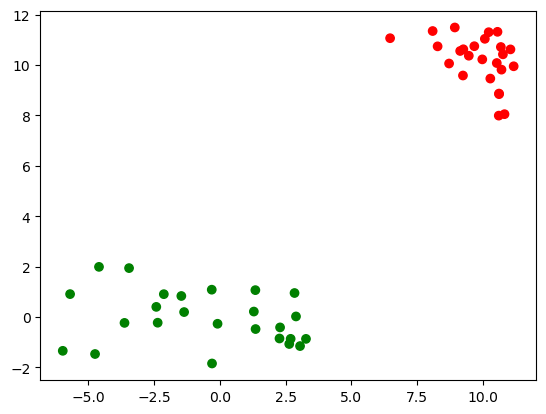

In [2]:
import matplotlib.pyplot as plt
import numpy as np
colors = np.array(['red', 'green', 'blue', 'yellow'])

n = 25

x1 = np.random.multivariate_normal([10, 10], cov=np.eye(2), size=n)
x1_idx = np.zeros(n, dtype=int)

x2 = np.random.multivariate_normal([0, 0], cov=np.array([[5, 0], [0, 1]]), size=n)
x2_idx = np.ones(n, dtype=int)

X = np.concatenate([x1, x2], axis=0)
X_idx = np.concatenate([x1_idx, x2_idx])

# create the plot and index into the colors array
plt.scatter(X[:, 0], X[:, 1], c=colors[X_idx])

## Exercise 1: Clusters!

In this exercise, you will train three different clustering algorithms on three different datasets. 

### Algorithms:
#### K-means 
* [Overview](https://scikit-learn.org/stable/modules/clustering.html#k-means)
* [Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans)

#### DBScan: 

* [Overview](https://scikit-learn.org/stable/modules/clustering.html#dbscan)
* [Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html#sklearn.cluster.DBSCAN)

#### GMM: 

* [Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html)

After reading the above documentation (You can skim it) attempt to explain to me like I'm five, what these algorithms are doing:
 

Explain how K-Means works?

>K-means initializes centroids, assigns each point to its nearest centroid, recomputes each centroid as the mean of its assigned points, and repeats until the assignments stabilize.

Explain how DBScan works?

>DBSCAN grows a cluster from dense neighborhoods: nearby core points expand the cluster, while points that do not belong to any dense neighborhood may be labeled as noise.

Explain how GMM works?

>A Gaussian mixture model represents each cluster with a Gaussian distribution and estimates the probability that each point belongs to every component. The final assignment is usually the component with the highest probability.

#### Datasets:
We will generate three toy datasets using the scikit-learn api, which you can do with the following code:

In [3]:
from sklearn import datasets
np.random.seed(0)

# ============
# Generate datasets. We choose the size big enough to see the scalability
# of the algorithms, but not too big to avoid too long running times
# ============
n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)[0]
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05)[0]
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)[0]

This generates three datasets, `noisy_circles`, `noisy_moons`, and `blobs`

Your Task: 
* We want you to train each clustering algorithm on each dataset (you should have a total of 9 plots).
* For each dataset/algorithm, plot the points. Color the points using the cluster the belong to

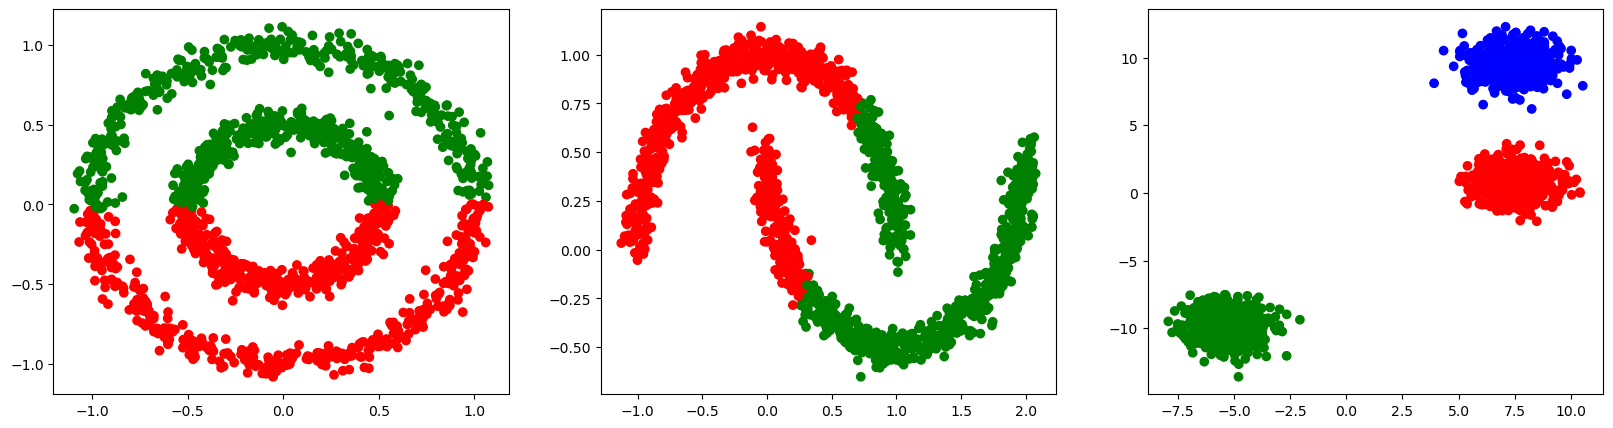

In [4]:
### --- K-Means --- ###
from sklearn.cluster import KMeans

fig, axs = plt.subplots(1,3,figsize=(20,5))

km_circles = KMeans(n_clusters=2).fit(noisy_circles)
km_circles_predictions = km_circles.predict(X=noisy_circles)
axs[0].scatter(x = noisy_circles[:,0], y = noisy_circles[:,1], c = colors[km_circles_predictions])

km_moons = KMeans(n_clusters=2).fit(noisy_moons)
km_moons_predictions = km_moons.predict(X=noisy_moons)
axs[1].scatter(x = noisy_moons[:,0], y = noisy_moons[:,1], c = colors[km_moons_predictions])

km_blobs = KMeans(n_clusters=3, random_state=0).fit(blobs)
km_blobs_prediction = km_blobs.predict(X=blobs)
axs[2].scatter(x = blobs[:,0], y = blobs[:,1], c = colors[km_blobs_prediction])

plt.show()

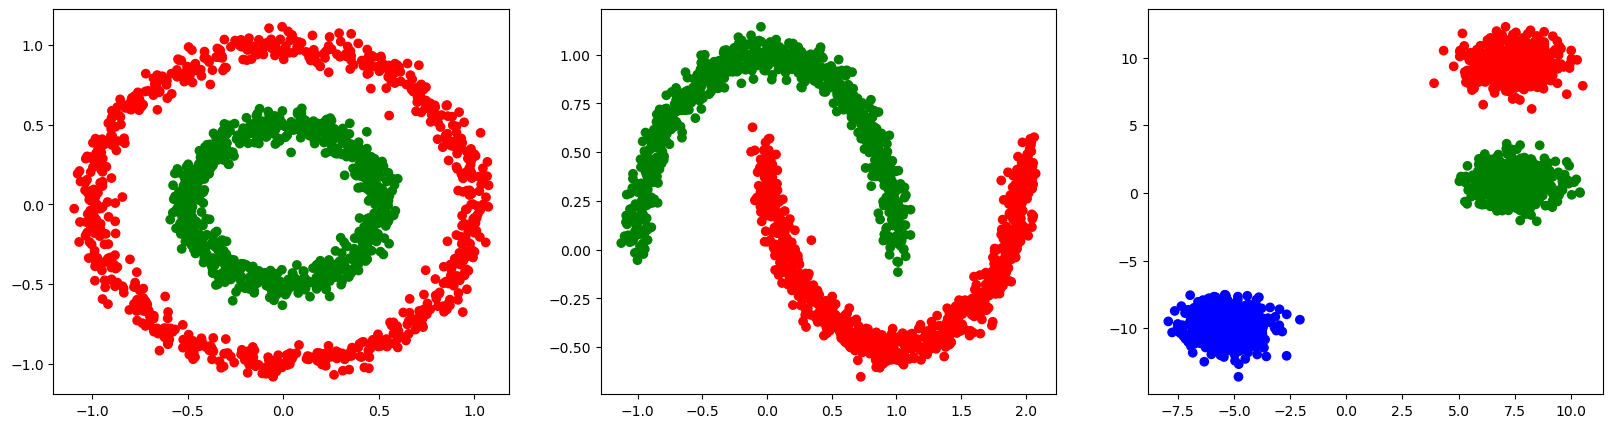

In [5]:
### --- DBScan --- ###
from sklearn.cluster import DBSCAN

fig, axs = plt.subplots(1,3,figsize=(20,5))

db_circles = DBSCAN(eps = 0.15).fit(noisy_circles)
db_circles_predictions = db_circles.fit_predict(X=noisy_circles)
axs[0].scatter(x = noisy_circles[:,0], y = noisy_circles[:,1], c = colors[db_circles_predictions])

db_moons = DBSCAN(eps = 0.15).fit(noisy_moons)
db_moons_predictions = db_moons.fit_predict(X=noisy_moons)
axs[1].scatter(x = noisy_moons[:,0], y = noisy_moons[:,1], c = colors[db_moons_predictions])

db_blobs = DBSCAN(eps = 1.5).fit(blobs)
db_blobs_predictions = db_blobs.fit_predict(X=blobs)
axs[2].scatter(x = blobs[:,0], y = blobs[:,1], c = colors[db_blobs_predictions])

plt.show()

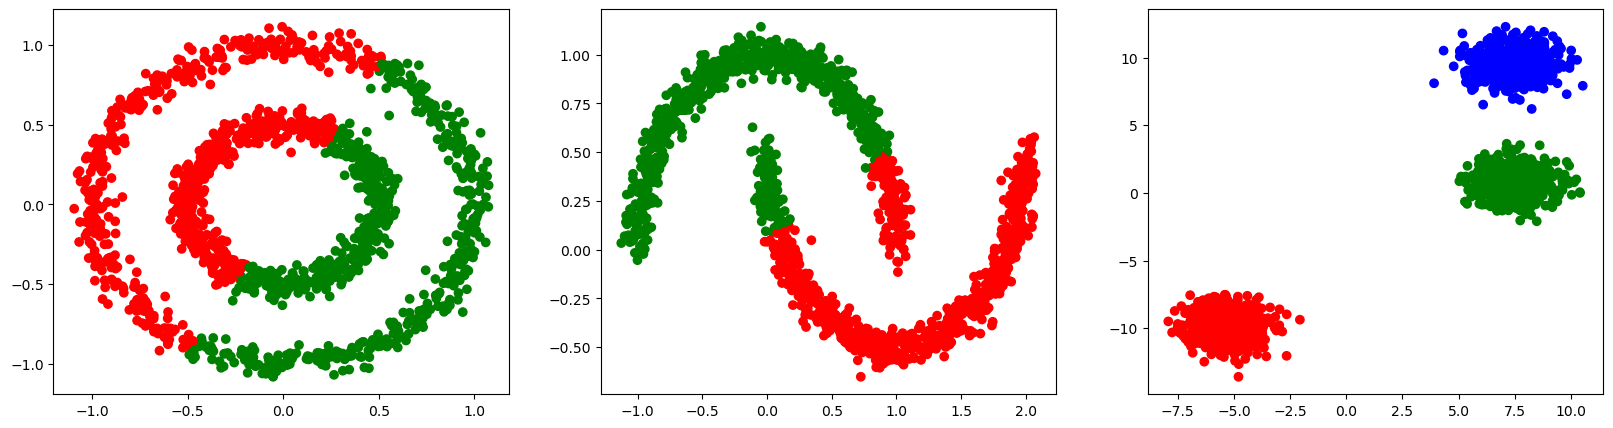

In [6]:
### --- GMM --- ###
from sklearn.mixture import GaussianMixture

fig, axs = plt.subplots(1,3,figsize=(20,5))

gm_circles = GaussianMixture(n_components=2, covariance_type='full').fit(noisy_circles)
gm_circles_predicions = gm_circles.fit_predict(X=noisy_circles)
axs[0].scatter(x = noisy_circles[:,0], y = noisy_circles[:,1], c = colors[gm_circles_predicions])

gm_moons = GaussianMixture(n_components=2, covariance_type='full').fit(noisy_moons)
gm_moons_predictions = gm_moons.fit_predict(X=noisy_moons)
axs[1].scatter(x = noisy_moons[:,0], y = noisy_moons[:,1], c = colors[gm_moons_predictions])

gm_blobs = GaussianMixture(n_components=3, covariance_type='full').fit(blobs)
gm_blobs_predictions = gm_blobs.fit_predict(X=blobs)
axs[2].scatter(x = blobs[:,0], y = blobs[:,1], c = colors[gm_blobs_predictions])

plt.show()

## Exercise 2: Flower Power Returns


In the previous exercise we looked simple datasets with 2 dimensions (features). In real life, we often have many more variables than. Clustering algorithms can also be applied to higher dimensional data. For this exercise train k-means on the Iris dataset, which has 4 dimensions (features). This is difficult visualize so we will also apply a dimensionality technique to the data to reduce to 2-D strictly to create a plot.

### Dataset
Download the iris dataset and cast to a numpy array

In [7]:
import statsmodels.api as sm
df = sm.datasets.get_rdataset(dataname='iris', package='datasets').data
X = df.iloc[:, :4].values

We know the iris dataset has three classes `['setosa', 'versicolor', 'virginica']`

Your Task: 
* Train K-means on the iris dataset with 3 clusters

In [8]:
from sklearn.cluster import KMeans
# your code goes here
km_iris = KMeans(n_clusters=3).fit(X)
km_iris_predictions = km_iris.predict(X=X)

clusters = km_iris_predictions

# clusters = get predicted clusters indices

Now let’s visualize the clusters by reducing the feature space to 2-D. This will allow us to create a plot. We will use T-distributed Stochastic Neighbor Embedding [sklearn.manifold.TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)

In [9]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2)
X_reduced = tsne.fit_transform(X)

/home/utahnu/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/home/utahnu/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


Your Task:
* Create a plot using X_reduced, where each point is colored according to its cluster id.

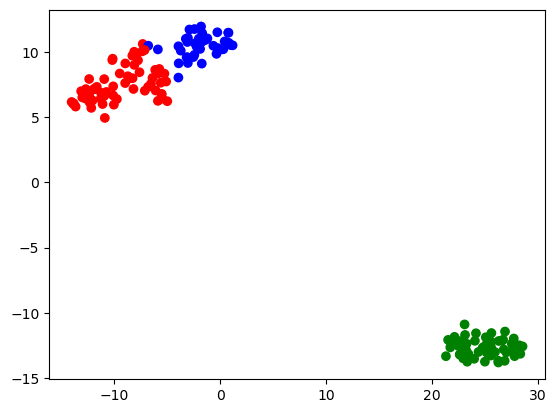

In [10]:
#Enter your code for the X_reduced plot here.
plt.scatter(x = X_reduced[:,0], y = X_reduced[:,1], c = colors[clusters])
plt.show()


Comment on your observations. Were we successfully able to group samples together without labels?

>The visualization shows three separated groups in the two-dimensional embedding. This is evidence that the measurements support useful groupings, but it does not prove that the unsupervised cluster IDs exactly match the species labels; the embedding itself can affect the appearance.

## Exercise 3: Split the Data

Use the train_test_split() function in sklearn (sklearn.model_selection.train_test_split ) to split the iris data set. Report the number of samples in both the train and test set.

In [11]:
df.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [12]:
from sklearn.model_selection import train_test_split

#Split the dataset here
XX = df.iloc[:, :4].values
yy = df.iloc[:,4].values
X_train, X_test, y_train, y_test = train_test_split(XX, yy, test_size=0.4, random_state=0)

print(XX.shape, X_train.shape, X_test.shape)
print(yy.shape, y_train.shape, y_test.shape)

(150, 4) (90, 4) (60, 4)
(150,) (90,) (60,)


What is the number of samples in the train set?

>$90$

What is the number of samples in the test set?

>$60$

## Exercise 4: K Nearest Neighbors

Your Task: 
* Train a K-nearest neighbors (sklearn.neighbors.KNeighborsClassifier ) on the iris data.

* Train your KNN when the n_neighbors parameter is 5. Report your train accuracy and test accuracy

* Perform a grid search over the parameter n_neighbors over the range 1-20:

* For each value of n_neighbors, fit a KNN and record your train and test accuracy

* Create a plot showing the test/train accuracy over the n_neighbors



In [13]:
from sklearn.neighbors import KNeighborsClassifier

In [14]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X=X_train, y=y_train)
y_hat = knn.predict(X=X_test)

get_accuracy = lambda y_true, y_hat: np.mean(y_true==y_hat)
print(get_accuracy(y_test, y_hat))

y_hat = knn.predict(X=X_train)
print(get_accuracy(y_train, y_hat))

0.95
1.0


/home/utahnu/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
/home/utahnu/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accept

In [15]:
accuracies = []
train_accuracies = []
for n in range(1,21):
    knn1 = KNeighborsClassifier(n_neighbors=n)
    knn1.fit(X=X_train, y=y_train)
    y_hat = knn1.predict(X=X_test)
    accuracies.append(get_accuracy(y_test, y_hat))
    y_hat = knn1.predict(X=X_train)
    train_accuracies.append(get_accuracy(y_train, y_hat))

/home/utahnu/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
/home/utahnu/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accept

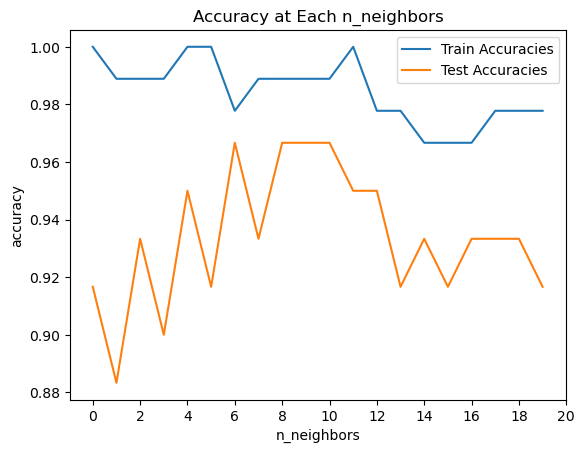

In [16]:
plt.plot(train_accuracies, label = "Train Accuracies")
plt.plot(accuracies, label = "Test Accuracies")
plt.xticks([0,2,4,6,8,10,12,14,16,18,20])
plt.xlabel('n_neighbors')
plt.ylabel('accuracy')
plt.title("Accuracy at Each n_neighbors")
plt.legend()
plt.show()

What is your train accuracy and test accuracy for when the n_neighbors parameter is 5

>With `n_neighbors=5`, the recorded train accuracy is `1.0` and the recorded test accuracy is `0.95` for this fixed split. These values depend on the split and preprocessing.

Discuss what you learn. How does train and test accuracy behave as you change the number of neighbors?

>As `n_neighbors` increases, the model becomes smoother: training accuracy generally decreases from the highly flexible one-neighbor case, while test accuracy may peak at an intermediate value before declining. The best value should be selected from validation results rather than assumed to be in the middle of the range.